# Crop Recommendation System — Model Implementation
### Minor Project-1 | JUET

This notebook covers the implementation phase: preprocessing recap, train-test split, training a Logistic Regression baseline and a Random Forest model, evaluating both, and saving the final model for later use in the Streamlit app.

**Dataset:** Kaggle Crop Recommendation Dataset (`Crop_recommendation.csv`)


## Step 1: Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Crop_recommendation.csv")
print(df.shape)
df.head()


(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Quick sanity checks — confirm no missing values and see how many crop classes we're predicting.

In [2]:
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [3]:
df['label'].value_counts()


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## Step 2: Separate features and target

In [4]:
X = df.drop('label', axis=1)   # N, P, K, temperature, humidity, ph, rainfall
y = df['label']                # crop name

X.head()


,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


## Step 3: Encode the target labels\n\n`label` is text (crop names). Encoding it to integers makes it easier to work with scikit-learn's classifiers and metrics.

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# keep this mapping - needed later to convert predictions back to crop names
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping


{'apple': np.int64(0),
 'banana': np.int64(1),
 'blackgram': np.int64(2),
 'chickpea': np.int64(3),
 'coconut': np.int64(4),
 'coffee': np.int64(5),
 'cotton': np.int64(6),
 'grapes': np.int64(7),
 'jute': np.int64(8),
 'kidneybeans': np.int64(9),
 'lentil': np.int64(10),
 'maize': np.int64(11),
 'mango': np.int64(12),
 'mothbeans': np.int64(13),
 'mungbean': np.int64(14),
 'muskmelon': np.int64(15),
 'orange': np.int64(16),
 'papaya': np.int64(17),
 'pigeonpeas': np.int64(18),
 'pomegranate': np.int64(19),
 'rice': np.int64(20),
 'watermelon': np.int64(21)}

## Step 4: Train-test split\n\n`stratify=y_encoded` keeps the crop-class proportions the same in both the train and test sets, since we have 22 different crop classes.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1760, 7)
Test shape: (440, 7)


## Step 5: Feature scaling\n\nLogistic Regression is distance/gradient based, so unscaled features (N, P, K on one scale, temperature/humidity/rainfall on another) hurt its performance. Random Forest doesn't need this, but scaling won't hurt it either.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Step 6: Train a Logistic Regression baseline

In [8]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)


## Step 7: Train a Random Forest model

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)   # Random Forest doesn't need scaled data

y_pred_rf = rf_model.predict(X_test)


## Step 8: Evaluate both models

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print(f"Random Forest Accuracy:       {acc_rf:.4f}")


Logistic Regression Accuracy: 0.9727
Random Forest Accuracy:       0.9955


In [11]:
print("Random Forest — Classification Report\n")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


Random Forest — Classification Report

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.0

### Confusion matrix\n\nGood visual for the presentation — shows exactly which crops (if any) the model confuses.

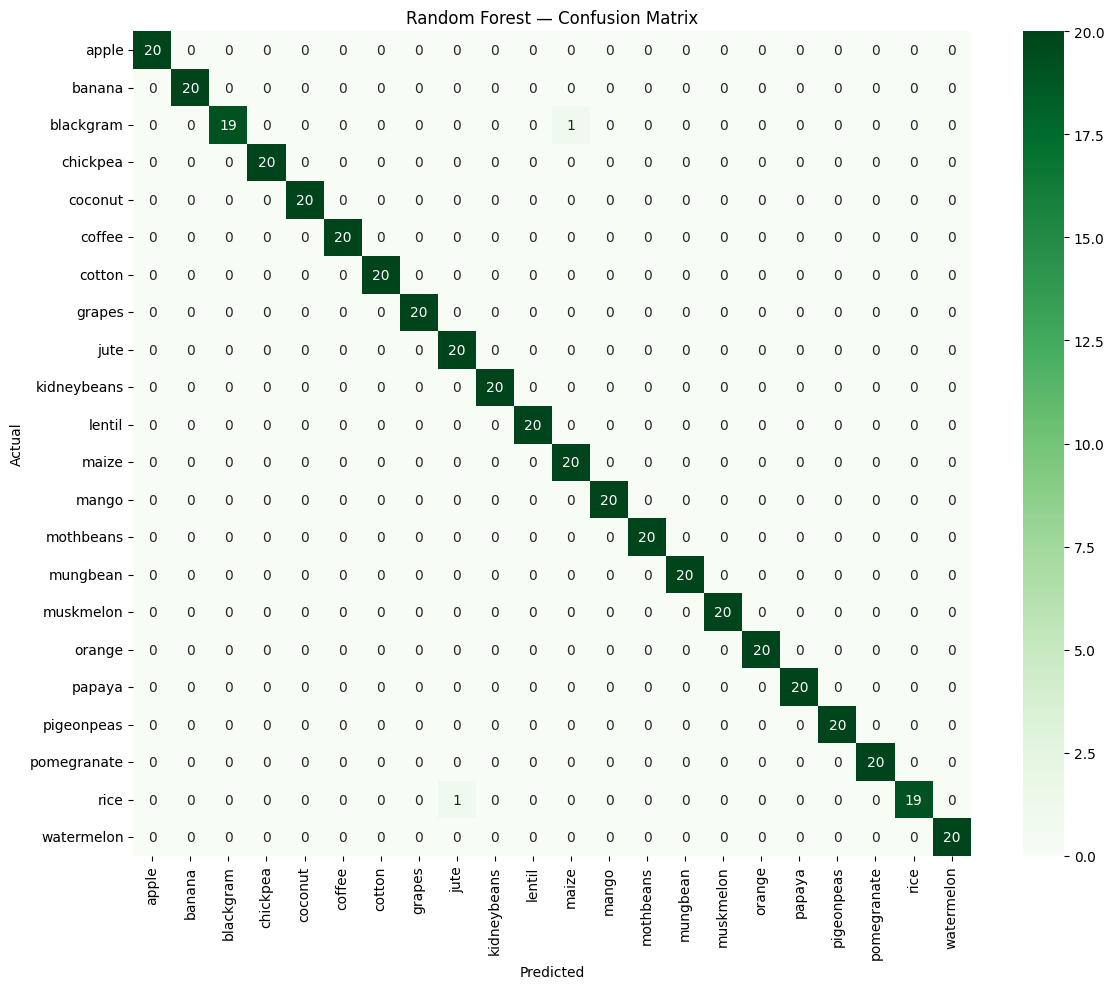

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()


## Step 9: Feature importance (Random Forest)\n\nShows which soil/climate factors the model relies on most — a good callback to the correlation analysis from Week 4's EDA.

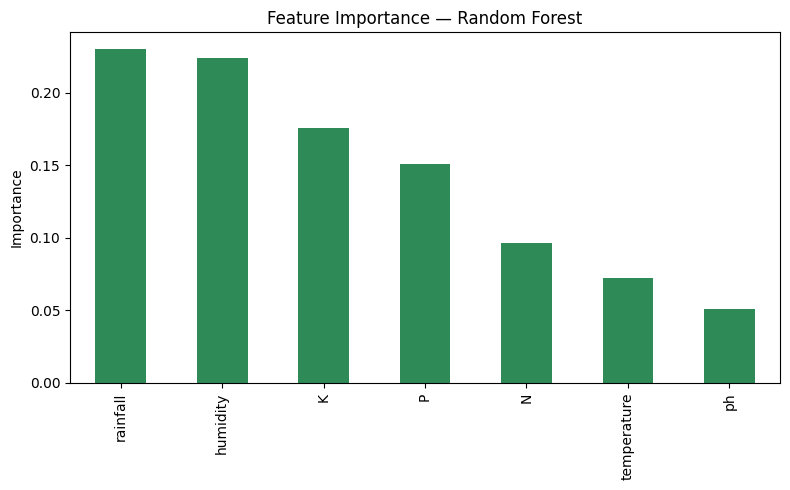

rainfall       0.230184
humidity       0.224227
K              0.175393
P              0.150850
N              0.096363
temperature    0.072375
ph             0.050608
dtype: float64

In [13]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='seagreen')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

importances


## Step 10: Model comparison summary

In [14]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [acc_log, acc_rf]
})
comparison


,Model,Accuracy
0,Logistic Regression,0.972727
1,Random Forest,0.995455


## Step 11: Save the trained model\n\nThese files are needed later to build the Streamlit web interface without retraining the model every time.

In [15]:
import joblib

joblib.dump(rf_model, 'crop_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Saved: crop_model.pkl, scaler.pkl, label_encoder.pkl")


Saved: crop_model.pkl, scaler.pkl, label_encoder.pkl


---
### Next steps
- Run k-fold cross-validation (`cross_val_score`) instead of a single train-test split, for a more reliable accuracy estimate.
- Try hyperparameter tuning on the Random Forest (`GridSearchCV` over `n_estimators`, `max_depth`) to see if accuracy improves further.
- Build the Streamlit interface using the saved `.pkl` files.
